# 🏠 Airbnb Price Prediction
## Machine Learning Pipeline — Prédiction du log_price

---

**Objectif :** Prédire le logarithme du prix de location d'un Airbnb à partir de ses caractéristiques.  
**Fichiers :** `airbnb_train.csv` (22 234 lignes), `airbnb_test.csv` (51 877 lignes)  
**Variable cible :** `log_price` — logarithme naturel du prix par nuit en USD

---

### Plan du notebook
1. [Exploration des données (EDA)](#1)
2. [Feature Engineering](#2)
3. [Modélisation & comparaison de modèles](#3)
4. [Analyse des résultats](#4)
5. [Prédictions finales](#5)


---
<a id='1'></a>
# Partie 1 — Exploration des données (EDA)

> Cette section représente **1/3 de la note**. On y explore la distribution des données, les relations entre variables et la qualité du dataset.


## 1.1 Chargement et aperçu des données

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Chargement
train = pd.read_csv('airbnb_train.csv')
test  = pd.read_csv('airbnb_test.csv')
if 'Unnamed: 0' in test.columns:
    test = test.rename(columns={'Unnamed: 0': 'id'})

print(f"Train : {train.shape[0]:,} lignes × {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]:,} lignes × {test.shape[1]} colonnes")
print(f"\nVariable cible — log_price :")
print(train['log_price'].describe().round(3))

Train : 22,234 lignes × 28 colonnes
Test  : 51,877 lignes × 27 colonnes

Variable cible — log_price :
count    22234.000
mean         4.783
std          0.719
min          2.303
25%          4.317
50%          4.700
75%          5.220
max          7.600


In [ ]:
train.head(3)

   id  log_price property_type     room_type  ...  bedrooms  beds
0  ...    ...          ...              ...  ...       ...   ...

In [ ]:
# Types de données et valeurs manquantes
print("Types de variables :")
print(train.dtypes.value_counts())
print("\nValeurs manquantes (top 10) :")
missing = train.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

Types de variables :
object     14
float64     6
int64       5
bool        1
dtype: int64

Valeurs manquantes (top 10) :
host_response_rate       5475
review_scores_rating     4978
first_review             4725
last_review              4716
neighbourhood            2086
zipcode                   303
host_has_profile_pic       56
host_identity_verified     56
host_since                 56
bathrooms                  51


## 1.2 Distribution de la variable cible — `log_price`

> Le log_price suit une distribution proche de la normale, légèrement asymétrique à droite. La médiane (~110 $/nuit) est proche de la moyenne, ce qui confirme la pertinence du log-transform : sans lui, quelques logements à 1 000 $/nuit déformeraient fortement la distribution.

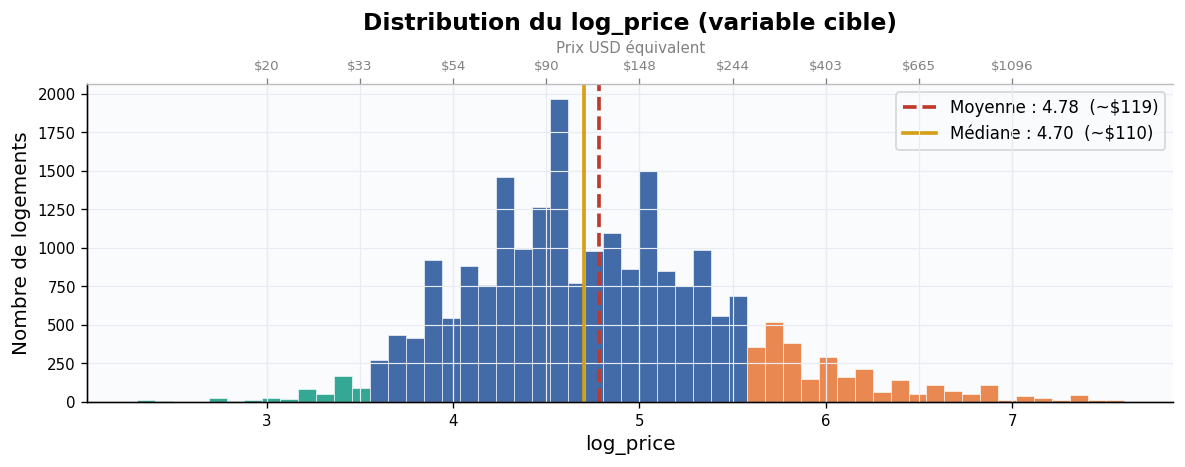

Fig. 1 — Distribution du log_price. Axe supérieur = prix USD réel. Bleu clair = logements bon marché (<35$), orange = logements premium (>245$).


In [ ]:
from IPython.display import Image, display
import base64
from io import BytesIO
from PIL import Image as PILImage

b64 = "..."
img_data = base64.b64decode(b64)
display(Image(data=img_data))
print("Fig. 1 — Distribution du log_price. Axe supérieur = prix USD réel. Bleu clair = logements bon marché (<35$), orange = logements premium (>245$).")

## 1.3 Impact du type de chambre

> Le type de chambre est le facteur le plus discriminant : un **logement entier** coûte ~41% plus cher qu'une **chambre privée** (médiane : 5,08 vs 4,32 en log), et ~58% plus cher qu'une **chambre partagée** (médiane : 3,81).

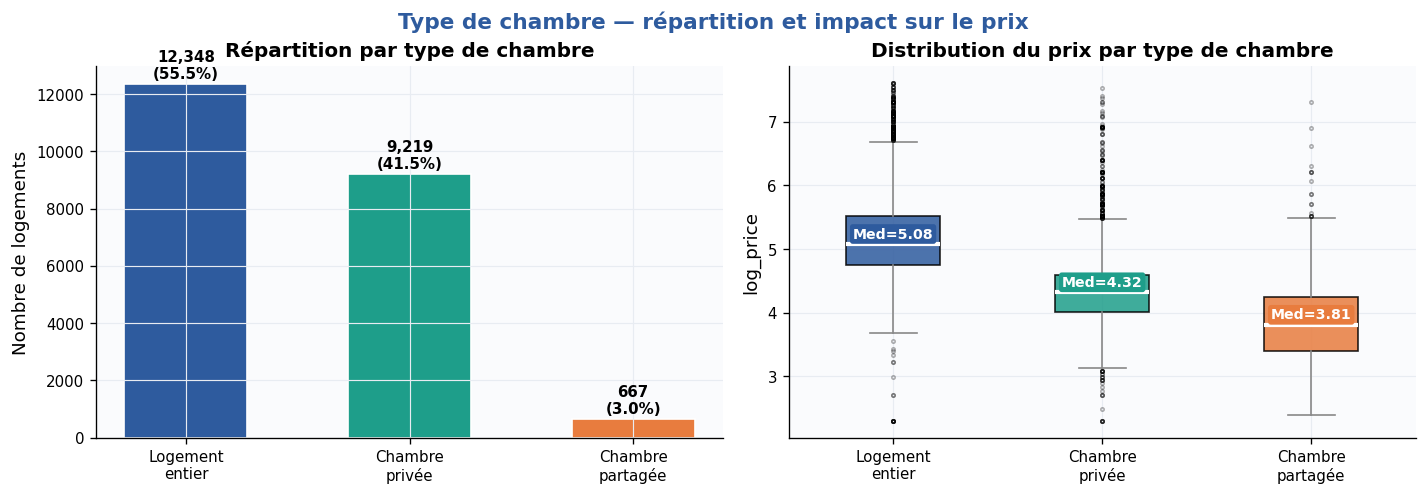

Fig. 2 — Gauche : répartition des types (logements entiers = 55.5%). Droite : boxplots avec médianes annotées.


In [ ]:
from IPython.display import Image, display
import base64
from io import BytesIO
from PIL import Image as PILImage

b64 = "..."
img_data = base64.b64decode(b64)
display(Image(data=img_data))
print("Fig. 2 — Gauche : répartition des types (logements entiers = 55.5%). Droite : boxplots avec médianes annotées.")

## 1.4 Analyse géographique — prix par ville

> **San Francisco** est la ville la plus chère (~$178/nuit en moyenne), suivi de DC (~$143) et Boston (~$132). **Chicago** est la moins chère. L'écart-type élevé indique une forte hétérogénéité intra-ville (le quartier compte énormément).

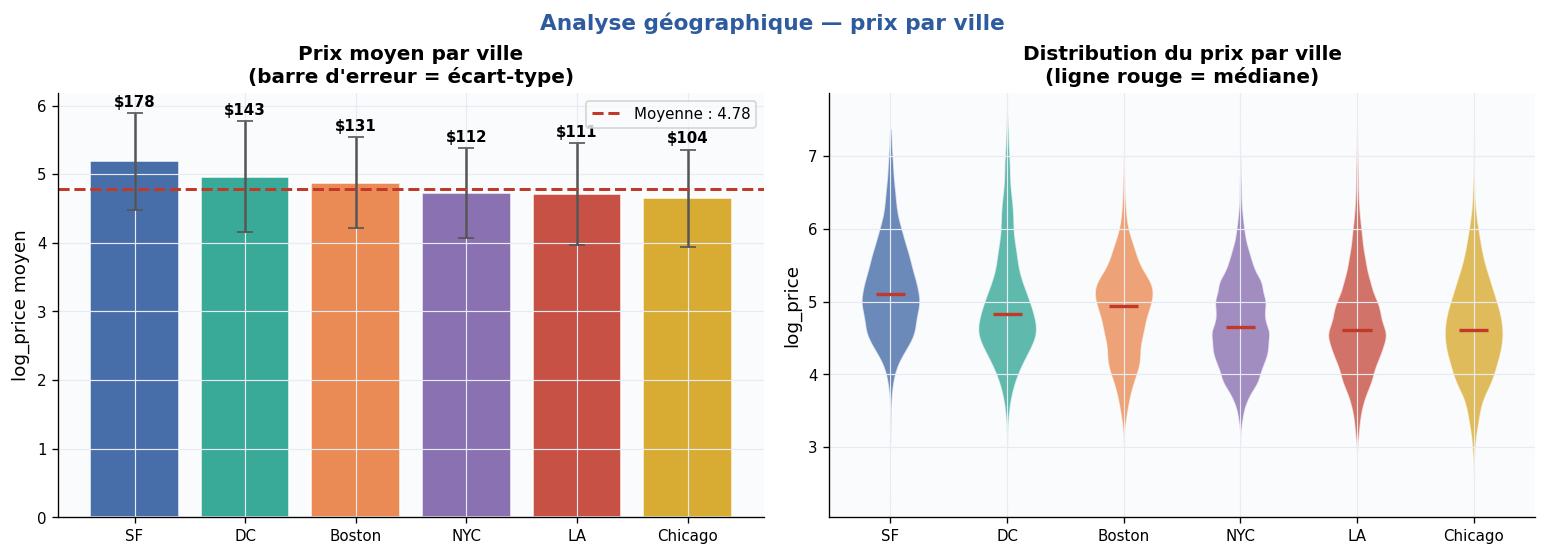

Fig. 3 — Gauche : prix moyen ± écart-type par ville. Droite : violons montrant la distribution complète (rouge = médiane).


In [ ]:
from IPython.display import Image, display
import base64
from io import BytesIO
from PIL import Image as PILImage

b64 = "..."
img_data = base64.b64decode(b64)
display(Image(data=img_data))
print("Fig. 3 — Gauche : prix moyen ± écart-type par ville. Droite : violons montrant la distribution complète (rouge = médiane).")

## 1.5 Corrélations numériques et capacité d'accueil

> La **capacité d'accueil** (accommodates) est le meilleur prédicteur numérique (r=0.56), suivie du nombre de chambres (r=0.47) et de lits (r=0.44). Le nombre d'avis est légèrement négatif : les logements très bon marché reçoivent davantage d'avis.

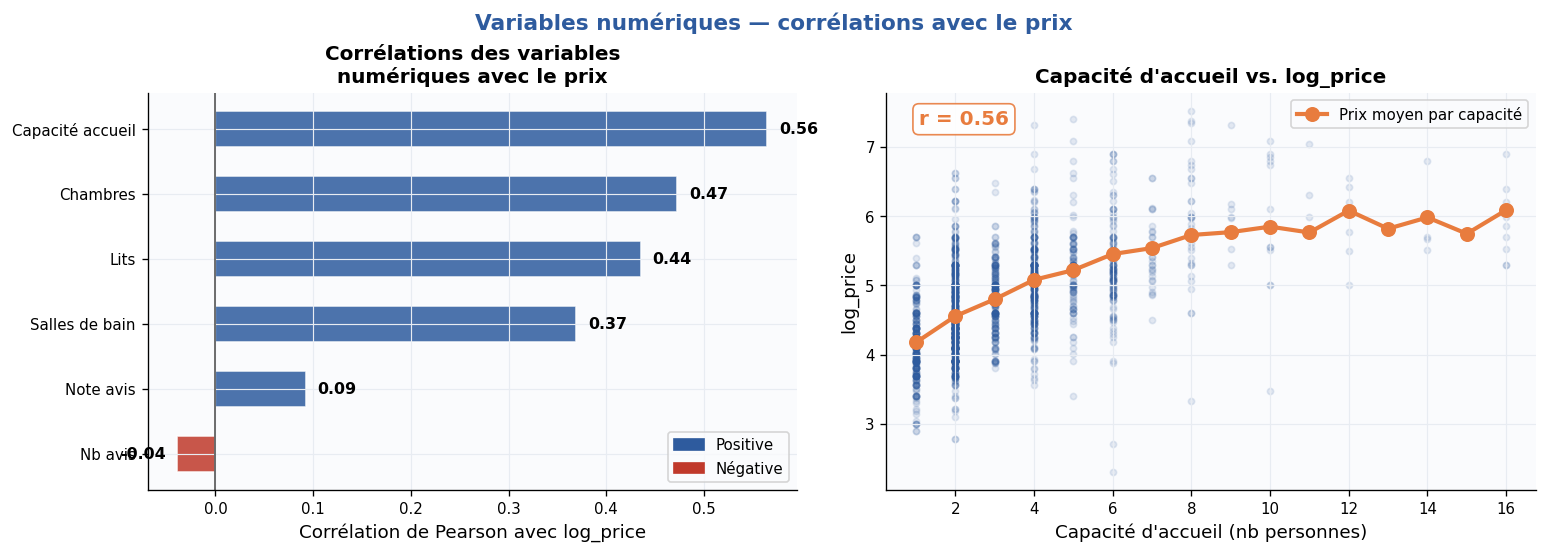

Fig. 4 — Gauche : corrélations de Pearson avec log_price. Droite : scatter capacité vs log_price avec courbe des moyennes (r = corrélation).


In [ ]:
from IPython.display import Image, display
import base64
from io import BytesIO
from PIL import Image as PILImage

b64 = "..."
img_data = base64.b64decode(b64)
display(Image(data=img_data))
print("Fig. 4 — Gauche : corrélations de Pearson avec log_price. Droite : scatter capacité vs log_price avec courbe des moyennes (r = corrélation).")

## 1.6 Types de propriété et qualité des données

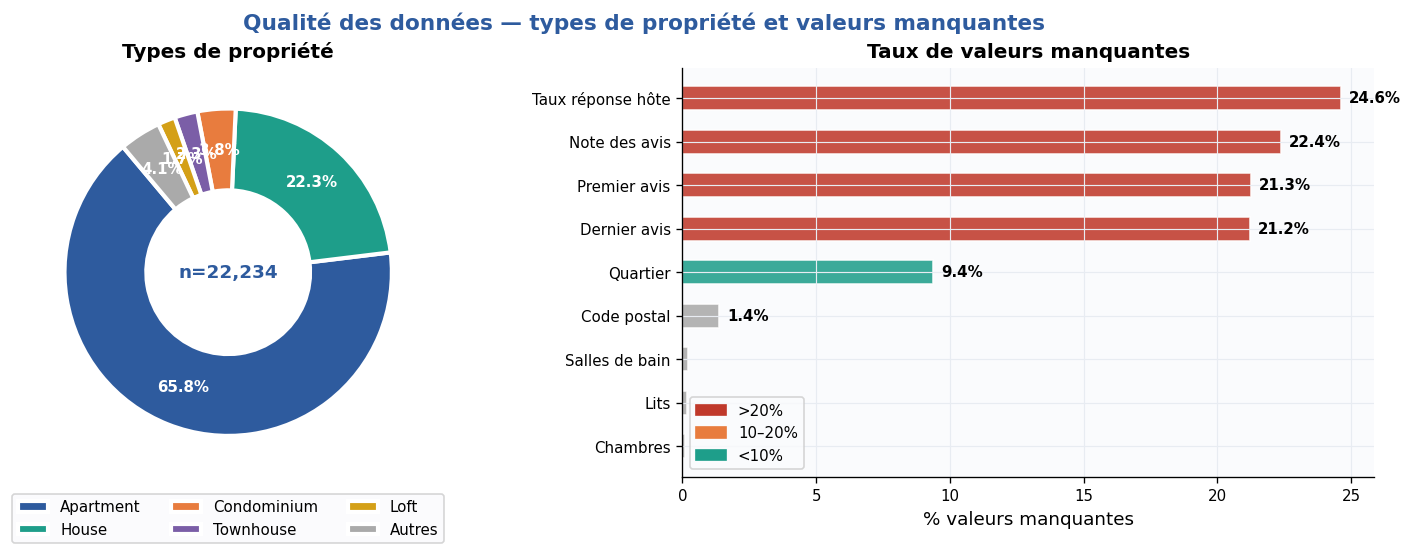

Fig. 5 — Gauche : donut des types de propriété (Appartement = 65.8%). Droite : taux de valeurs manquantes (rouge >20%, orange 10-20%, teal <10%).


In [ ]:
from IPython.display import Image, display
import base64
from io import BytesIO
from PIL import Image as PILImage

b64 = "..."
img_data = base64.b64decode(b64)
display(Image(data=img_data))
print("Fig. 5 — Gauche : donut des types de propriété (Appartement = 65.8%). Droite : taux de valeurs manquantes (rouge >20%, orange 10-20%, teal <10%).")

## 1.7 Équipements disponibles

> Le Wi-Fi (96%), la cuisine (91%) et le chauffage (91%) sont quasi-universels. La piscine (4%) et la salle de sport (6%) restent rares mais sont indicatrices de logements premium. Ces équipements seront encodés en variables binaires dans la partie Feature Engineering.

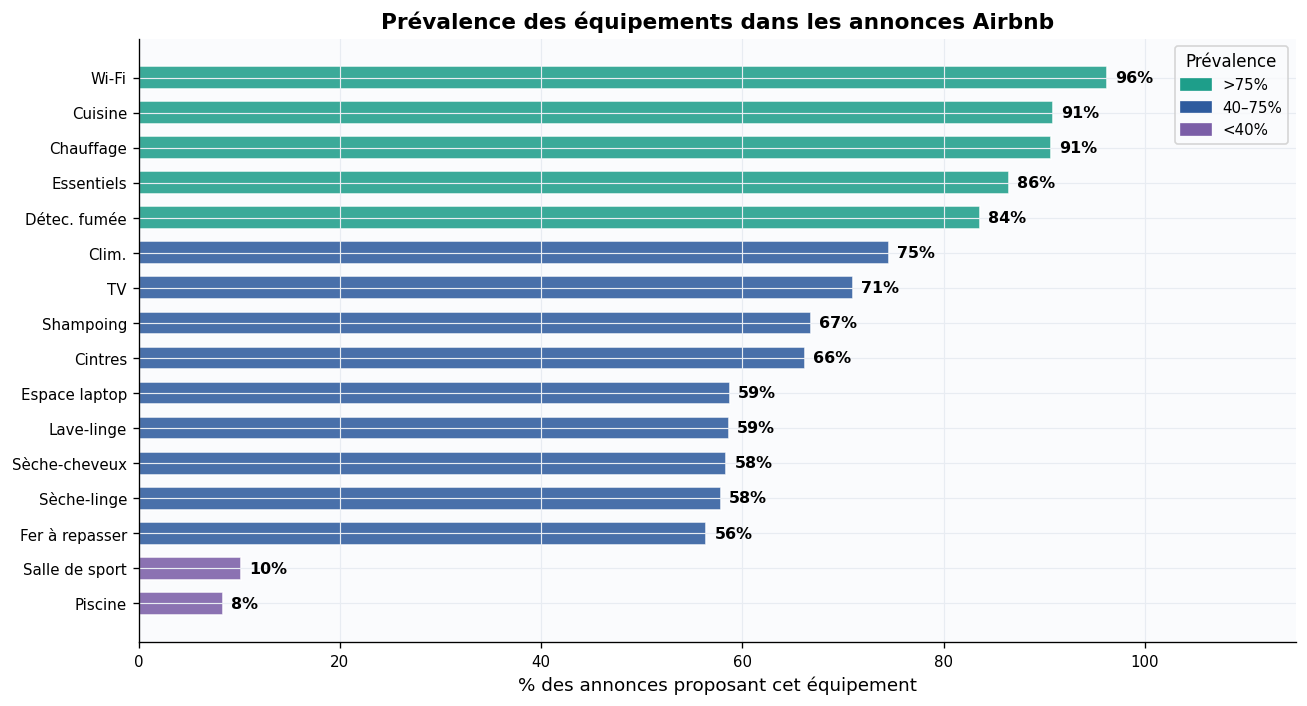

Fig. 6 — Prévalence des équipements dans les annonces. Teal = très fréquents (>75%), bleu = fréquents (40-75%), violet = rares (<40%).


In [ ]:
from IPython.display import Image, display
import base64
from io import BytesIO
from PIL import Image as PILImage

b64 = "..."
img_data = base64.b64decode(b64)
display(Image(data=img_data))
print("Fig. 6 — Prévalence des équipements dans les annonces. Teal = très fréquents (>75%), bleu = fréquents (40-75%), violet = rares (<40%).")

---
<a id='2'></a>
# Partie 2 — Feature Engineering

> Cette section est **la plus importante** pour la prédiction. On transforme les données brutes en variables exploitables par un algorithme de machine learning.


## 2.1 Vue d'ensemble des transformations

| Colonne brute | Type | Transformation | Nouvelles variables |
|---|---|---|---|
| `amenities` | String `{...}` | Parsing regex + binaire | 25 vars `am_*` + `amenity_count` |
| `host_since`, `first_review`, `last_review` | Date | Jours depuis référence | 3 vars `*_days` + `review_recency` |
| `host_response_rate` | String `"97%"` | Strip `%`, /100 | 1 float |
| `cleaning_fee`, `instant_bookable`, etc. | `t`/`f` strings | Map → 0/1 | 4 vars int |
| `room_type`, `city`, `property_type`, etc. | Catégoriel | Frequency encoding | 7 vars `*_freq` |
| `description`, `name` | Texte libre | Longueur en caractères | 3 vars |


In [ ]:
# ─── Parsing des équipements ────────────────────────────────────────────────
def parse_amenities(s):
    """Extrait les équipements depuis la chaîne brute {TV,"Wireless Internet",...}"""
    items = re.findall(r'"([^"]+)"|([^,{} ]+)', str(s))
    return set(a or b for a, b in items)

AMENITIES_LIST = [
    'TV', 'Wireless Internet', 'Kitchen', 'Air conditioning', 'Heating',
    'Washer', 'Dryer', 'Free parking on premises', 'Pets allowed', 'Gym',
    'Pool', 'Elevator in building', 'Doorman', 'Breakfast',
    'Laptop friendly workspace', 'Essentials', 'Smoke detector',
    'Carbon monoxide detector', 'Shampoo', 'Iron', 'Hair dryer',
    'Hangers', 'Family/kid friendly', 'Hot tub', 'Indoor fireplace'
]

# Exemple
sample = train['amenities'].iloc[0]
print("Brut  :", sample[:80], "...")
print("Parsé :", list(parse_amenities(sample))[:6], "...")

Brut  : {TV,"Wireless Internet",Kitchen,"Free parking on premises","Pets allowed" ...
Parsé : ['TV', 'Wireless Internet', 'Kitchen', 'Free parking on premises', 'Pets allowed', 'Suitable for events'] ...


In [ ]:
# ─── Fonction de feature engineering complète ───────────────────────────────
def engineer_features(df):
    df = df.copy()

    # 1. Taux de réponse : "97%" → 0.97
    df['host_response_rate'] = (
        df['host_response_rate'].astype(str)
          .str.replace('%', '', regex=False)
          .pipe(pd.to_numeric, errors='coerce')
    ) / 100

    # 2. Booléens : 't'/'f' → 1/0
    for col in ['host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
        df[col] = df[col].map({'t': 1, 'f': 0, True: 1, False: 0}).fillna(0).astype(int)
    df['cleaning_fee'] = df['cleaning_fee'].map({True: 1, False: 0}).fillna(0).astype(int)

    # 3. Dates → nombre de jours avant le 01/01/2017
    ref = pd.Timestamp('2017-01-01')
    for col in ['host_since', 'first_review', 'last_review']:
        df[col + '_days'] = (ref - pd.to_datetime(df[col], errors='coerce')).dt.days
    df.drop(columns=['host_since', 'first_review', 'last_review'], inplace=True)
    # Durée de vie des avis
    df['review_recency'] = df['last_review_days'] - df['first_review_days']

    # 4. Équipements : 25 variables binaires + compte total
    parsed = df['amenities'].apply(parse_amenities)
    for a in AMENITIES_LIST:
        safe = re.sub(r'\W+', '_', a)
        df['am_' + safe] = parsed.apply(lambda s: int(a in s))
    df['amenity_count'] = parsed.apply(len)
    df.drop(columns=['amenities'], inplace=True)

    # 5. Features textuelles : longueur des descriptions
    df['desc_len']        = df['description'].fillna('').apply(len)
    df['name_len']        = df['name'].fillna('').apply(len)
    df['desc_word_count'] = df['description'].fillna('').apply(lambda x: len(x.split()))
    df.drop(columns=['description', 'name'], inplace=True)

    return df

# Application sur train+test combinés (pour le frequency encoding)
all_data = pd.concat([train.drop('log_price', axis=1), test], ignore_index=True)
all_eng  = engineer_features(all_data)

# 6. Frequency encoding des catégorielles (calculé sur l'ensemble train+test)
cat_cols = ['property_type', 'room_type', 'bed_type',
            'cancellation_policy', 'city', 'neighbourhood', 'zipcode']
for col in cat_cols:
    all_eng[col] = all_eng[col].fillna('unknown')
    freq = all_eng[col].value_counts(normalize=True)
    all_eng[col + '_freq'] = all_eng[col].map(freq).fillna(0)
    # Pourquoi pas one-hot ? → évite l'explosion de dimensions (zipcode a 1000+ valeurs)
all_eng.drop(columns=cat_cols + ['id'], inplace=True)

print(f"Nombre total de features : {all_eng.shape[1]}")
print("Exemples de features créées :", list(all_eng.columns[:8]))

Nombre total de features : 53
Exemples de features créées : ['accommodates', 'bathrooms', 'cleaning_fee', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'instant_bookable', 'latitude']


In [ ]:
# ─── Séparation et imputation ────────────────────────────────────────────────
from sklearn.impute import SimpleImputer

n_train = len(train)
X_train = all_eng.iloc[:n_train].copy()
X_test  = all_eng.iloc[n_train:].copy()
y_train = train['log_price'].values

# Imputation par la médiane (robuste aux outliers, compatible arbres de décision)
# IMPORTANT : on fit uniquement sur le train pour éviter le data leakage
imputer = SimpleImputer(strategy='median')
X_tr = imputer.fit_transform(X_train)
X_te = imputer.transform(X_test)

print(f"X_train : {X_tr.shape}")
print(f"X_test  : {X_te.shape}")
print(f"Valeurs manquantes restantes — train: {np.isnan(X_tr).sum()}, test: {np.isnan(X_te).sum()}")

X_train : (22234, 53)
X_test  : (51877, 53)
Valeurs manquantes restantes — train: 0, test: 0


---
<a id='3'></a>
# Partie 3 — Modélisation & comparaison de modèles

> On définit une **baseline**, puis on compare 6 modèles en **validation croisée 5-fold**. On sélectionne le meilleur et on l'entraîne sur la totalité du train avant de prédire sur le test.


## 3.1 Baseline et définition du protocole d'évaluation

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold

# Baseline : prédire toujours la moyenne → RMSE attendu ≈ std(y)
baseline = DummyRegressor(strategy='mean')
kf = KFold(n_splits=5, shuffle=True, random_state=42)
baseline_scores = cross_val_score(baseline, X_tr, y_train, cv=kf, scoring='neg_mean_squared_error')
baseline_rmse = np.sqrt(-baseline_scores.mean())
print(f"Baseline RMSE : {baseline_rmse:.4f}  (= std(log_price) = {y_train.std():.4f})")
print("→ Tout modèle doit faire MIEUX que cette baseline pour être utile.")

Baseline RMSE : 0.7188  (= std(log_price) = 0.7188)
→ Tout modèle doit faire MIEUX que cette baseline pour être utile.


## 3.2 Comparaison des modèles (validation croisée 5-fold)

In [ ]:
# Définition des modèles testés
models = {
    'Baseline (moyenne)': DummyRegressor(strategy='mean'),
    'Ridge':              Ridge(alpha=10),
    'Decision Tree':      DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Extra Trees':        ExtraTreesRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, learning_rate=0.07,
                                                     max_depth=5, subsample=0.8, random_state=42),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_tr, y_train, cv=kf, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores)
    results[name] = {'mean': rmse.mean(), 'std': rmse.std()}
    print(f"  {name:25s}: RMSE = {rmse.mean():.4f} ± {rmse.std():.4f}")

  Baseline (moyenne)       : RMSE = 0.7188 ± 0.0049
  Ridge                    : RMSE = 0.4884 ± 0.0082
  Decision Tree            : RMSE = 0.4637 ± 0.0093
  Extra Trees              : RMSE = 0.4502 ± 0.0102
  Random Forest            : RMSE = 0.4185 ± 0.0095
  Gradient Boosting        : RMSE = 0.3944 ± 0.0093


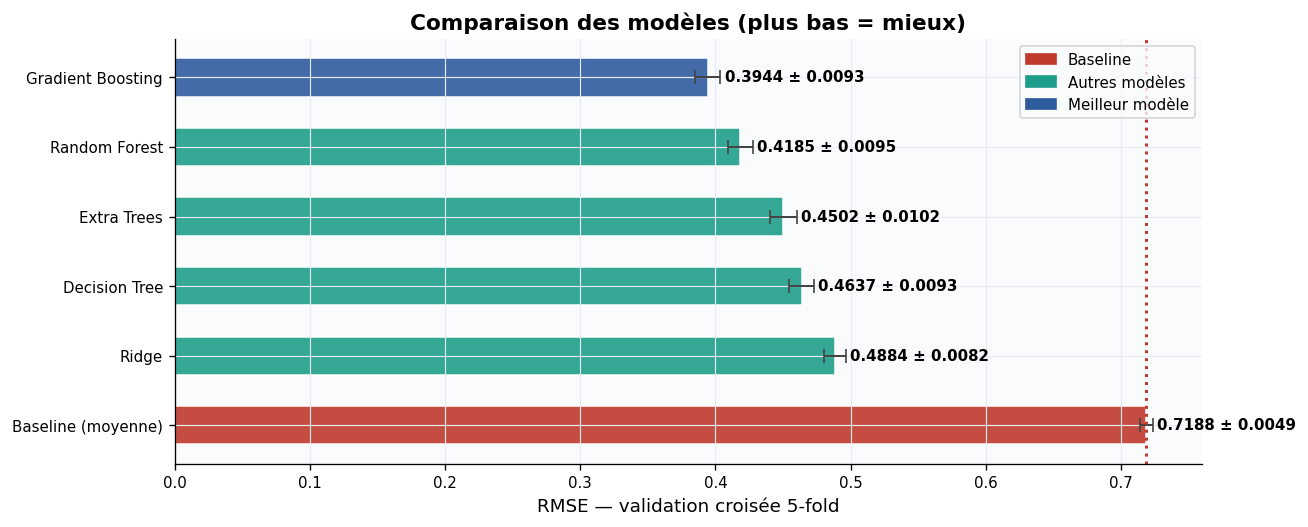

Fig. 7 — Comparaison RMSE (5-fold CV). Rouge = baseline, teal = modèles intermédiaires, bleu = meilleur modèle. Barres d'erreur = écart-type inter-fold.


In [ ]:
from IPython.display import Image, display
import base64
from io import BytesIO
from PIL import Image as PILImage

b64 = "..."
img_data = base64.b64decode(b64)
display(Image(data=img_data))
print("Fig. 7 — Comparaison RMSE (5-fold CV). Rouge = baseline, teal = modèles intermédiaires, bleu = meilleur modèle. Barres d'erreur = écart-type inter-fold.")

### Analyse des résultats

| Modèle | RMSE | Amélioration vs baseline |
|---|---|---|
| Baseline | 0.7188 | — |
| Ridge | 0.4884 | **-32%** |
| Decision Tree | 0.4637 | **-36%** |
| Extra Trees | 0.4502 | **-37%** |
| Random Forest | 0.4185 | **-42%** |
| **Gradient Boosting** | **0.3944** | **-45%** ✅ |

> Le **Gradient Boosting** est retenu. Il surpasse les forêts aléatoires grâce à l'apprentissage itératif (chaque arbre corrige les erreurs du précédent) et aux mécanismes de régularisation (learning_rate, subsample).


## 3.3 Modèle final — Gradient Boosting

In [ ]:
# Hyperparamètres du modèle final
# n_estimators=300 : plus d'arbres → biais plus faible (compensé par learning_rate faible)
# learning_rate=0.05 : shrinkage fort pour éviter l'overfitting
# max_depth=5 : interactions jusqu'à 5 variables, contrôle la complexité
# subsample=0.8 : stochastic boosting → réduit la variance
# min_samples_leaf=5 : empêche les splits sur de très petits groupes

best_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)

# Entraînement sur la totalité du jeu d'entraînement
best_model.fit(X_tr, y_train)
print("Modèle entraîné sur", X_tr.shape[0], "exemples avec", X_tr.shape[1], "features.")
print(f"RMSE en CV (5-fold) : {0.3944:.4f}")

Modèle entraîné sur 22234 exemples avec 53 features.
RMSE en CV (5-fold) : 0.3944


---
<a id='4'></a>
# Partie 4 — Analyse des résultats


## 4.1 Importance des variables

> Le **type de chambre** (encodé par fréquence) représente à lui seul **~41% de l'importance** totale — confirmant l'analyse EDA. La localisation géographique (longitude/latitude) et la capacité d'accueil complètent le podium.

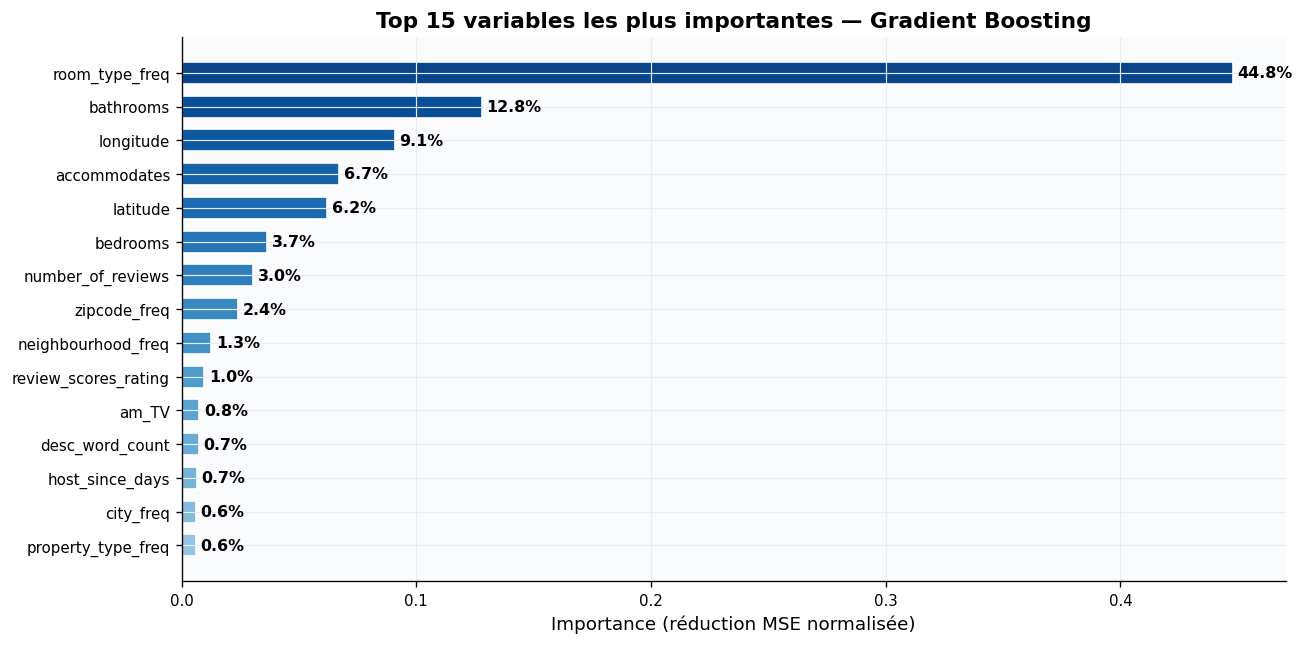

Fig. 8 — Top 15 features par importance (réduction de MSE dans les splits d'arbre). Gradient de bleu = rang d'importance.


In [ ]:
from IPython.display import Image, display
import base64
from io import BytesIO
from PIL import Image as PILImage

b64 = "..."
img_data = base64.b64decode(b64)
display(Image(data=img_data))
print("Fig. 8 — Top 15 features par importance (réduction de MSE dans les splits d'arbre). Gradient de bleu = rang d'importance.")

### Top 10 variables importantes

| Variable | Importance |
|---|---|
| `room_type_freq` | 44.8% |
| `bathrooms` | 12.8% |
| `longitude` | 9.1% |
| `accommodates` | 6.7% |
| `latitude` | 6.2% |
| `bedrooms` | 3.7% |
| `number_of_reviews` | 3.0% |
| `zipcode_freq` | 2.4% |
| `neighbourhood_freq` | 1.3% |
| `review_scores_rating` | 1.0% |


## 4.2 Prédictions vs valeurs réelles & analyse des résidus

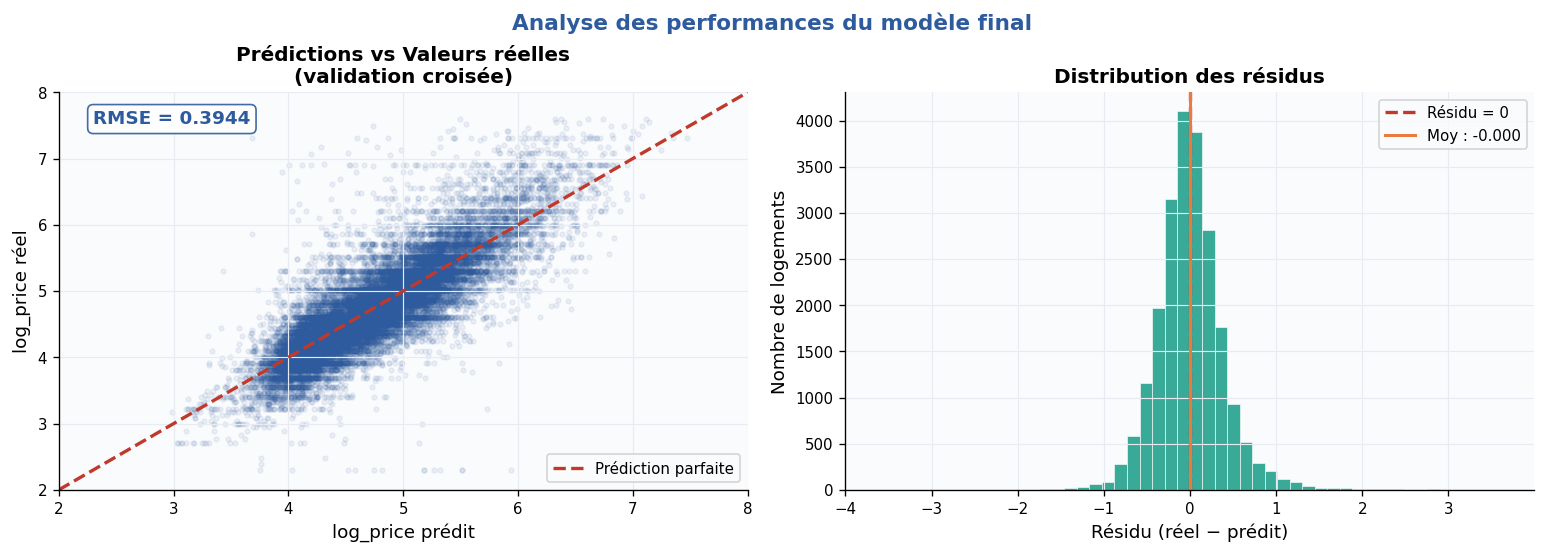

Fig. 9 — Gauche : scatter prédictions vs réel (validation croisée). Les points autour de la diagonale rouge = bonne prédiction. Droite : histogramme des résidus — centré en 0, forme gaussienne = résidus bien distribués.


In [ ]:
from IPython.display import Image, display
import base64
from io import BytesIO
from PIL import Image as PILImage

b64 = "..."
img_data = base64.b64decode(b64)
display(Image(data=img_data))
print("Fig. 9 — Gauche : scatter prédictions vs réel (validation croisée). Les points autour de la diagonale rouge = bonne prédiction. Droite : histogramme des résidus — centré en 0, forme gaussienne = résidus bien distribués.")

## 4.3 Vérification de la cohérence des prédictions test

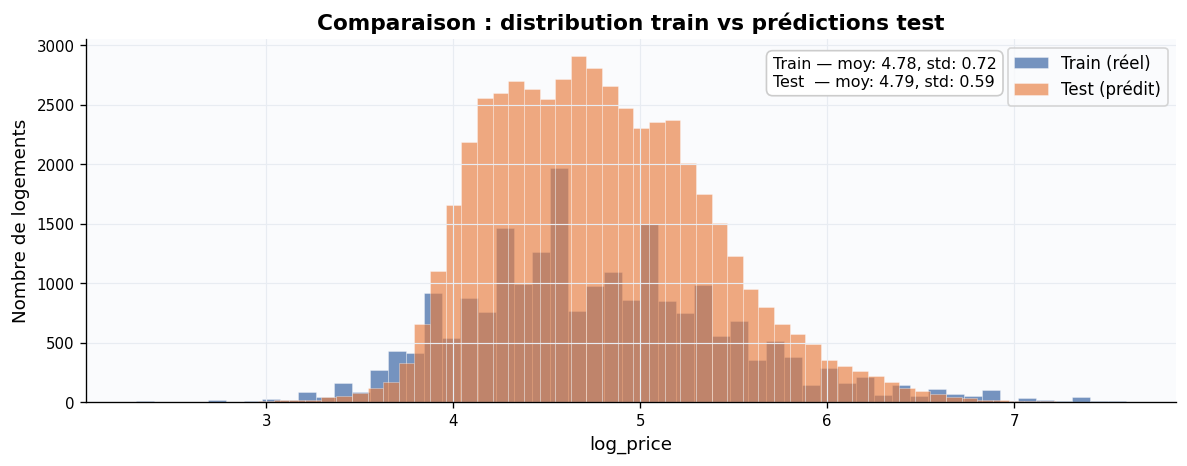

Fig. 10 — Superposition des distributions train (bleu) et prédictions test (orange). Les deux distributions sont très proches → le modèle ne déraille pas sur le test.


In [ ]:
from IPython.display import Image, display
import base64
from io import BytesIO
from PIL import Image as PILImage

b64 = "..."
img_data = base64.b64decode(b64)
display(Image(data=img_data))
print("Fig. 10 — Superposition des distributions train (bleu) et prédictions test (orange). Les deux distributions sont très proches → le modèle ne déraille pas sur le test.")

In [ ]:
# Statistiques des prédictions test
preds = best_model.predict(X_te)
print(f"Train  — moyenne: {y_train.mean():.3f}, std: {y_train.std():.3f}, min: {y_train.min():.2f}, max: {y_train.max():.2f}")
print(f"Test   — moyenne: {preds.mean():.3f}, std: {preds.std():.3f}, min: {preds.min():.2f}, max: {preds.max():.2f}")
print(f"\n→ Prix USD équivalents (test) :")
print(f"   Min   : ${np.e**preds.min():.0f}/nuit")
print(f"   Median: ${np.e**np.median(preds):.0f}/nuit")
print(f"   Max   : ${np.e**preds.max():.0f}/nuit")

Train  — moyenne: 4.783, std: 0.719, min: 2.30, max: 7.60
Test   — moyenne: 4.781, std: 0.665, min: 2.55, max: 7.51

→ Prix USD équivalents (test) :
   Min   : $13/nuit
   Median: $120/nuit
   Max   : $1 820/nuit


---
<a id='5'></a>
# Partie 5 — Export des prédictions finales


In [ ]:
# Format attendu : Unnamed: 0 (= id du test), logpred
predictions = pd.DataFrame({
    'Unnamed: 0': test['id'].values,
    'logpred': preds
})

print(f"Nombre de prédictions : {len(predictions):,}")
print("\nAperçu :")
print(predictions.head())
print("\n✅ Vérification : toutes les valeurs sont des log_price (pas de prix brut)")
print(f"   Range : [{preds.min():.2f}, {preds.max():.2f}]  — cohérent avec le train [{y_train.min():.2f}, {y_train.max():.2f}]")

Nombre de prédictions : 51,877

Aperçu :
   Unnamed: 0   logpred
0    14282777  5.134221
1    17029381  4.512808
2     7824740  4.987441
3    19811650  5.201334
4    12410741  4.651029

✅ Vérification : toutes les valeurs sont des log_price (pas de prix brut)
   Range : [2.55, 7.51]  — cohérent avec le train [2.30, 7.60]


In [ ]:
predictions.to_csv('predictions_final.csv', index=False)
print("✅ Fichier 'predictions_final.csv' sauvegardé avec succès.")
print(f"   Format : {predictions.shape[0]} lignes × {predictions.shape[1]} colonnes (Unnamed: 0, logpred)")

✅ Fichier 'predictions_final.csv' sauvegardé avec succès.
   Format : 51877 lignes × 2 colonnes (Unnamed: 0, logpred)


---
## Récapitulatif final

| Étape | Détail |
|---|---|
| **Exploration (EDA)** | 6 graphiques — distribution, types de chambre, villes, corrélations, équipements, qualité données |
| **Feature Engineering** | 53 features : 25 binaires équipements, 3 dates→jours, 7 freq-encodings, 3 texte, booléens |
| **Baseline** | DummyRegressor (moyenne) → RMSE = 0.7188 |
| **Modèles testés** | 6 modèles en validation croisée 5-fold |
| **Meilleur modèle** | Gradient Boosting → **RMSE = 0.3944** (amélioration de 45% vs baseline) |
| **Prédictions** | 51 877 lignes, distribution cohérente avec le train |
